In [35]:
import numpy as np
import ray
import matplotlib.pyplot as plt
import pythtb
import wannierberri as wberri
from wannierberri.system import System_PythTB
from wannierberri.evaluate_k import evaluate_k_path
from hall_ps.hall_positional_shift import HallPositionalShift
import ray

# WannierBerri k.p

In [25]:
def model_ferroaxial_pythtb(mu=0.0, t=1.0, tp=1.0, Delta=1.0, tpz=1.0, tc=0.0, a=1.0, c=1.0):
    
    lat = np.array([[1.5*a, -np.sqrt(3)/2*a, 0], [1.5*a,  np.sqrt(3)/2*a, 0], [0, 0, c]])
    orb = np.array([[0, 0, 0], [1/3, 1/3, 0]])
    
    my_model = tb_model(3, 3, lat, orb)
    my_model.set_onsite([Delta - mu, -Delta - mu])

    # Off-diagonal Hoppings (A to B)
    my_model.set_hop(t, 0, 1, [0, 0, 0]) 
    my_model.set_hop(t, 0, 1, [0, 1, 0]) 
    my_model.set_hop(t, 0, 1, [1, 0, 0]) 

    # Third Neighbor Hoppings (tp)
    my_model.set_hop( tp, 0, 1, [-1,  2,  0]) 
    my_model.set_hop( tp, 0, 1, [ 2,  0,  0])
    my_model.set_hop( tp, 0, 1, [-1, -1,  0])
    my_model.set_hop(-tp, 0, 1, [ 1,  1,  0]) 
    my_model.set_hop(-tp, 0, 1, [-2,  1,  0])
    my_model.set_hop(-tp, 0, 1, [ 1, -2,  0])

    # Vertical Hoppings (tpz)
    for shift in [[0,0,0], [0,1,0], [1,0,0]]:
        my_model.set_hop( tpz, 0, 1, [shift[0], shift[1],  1])
        my_model.set_hop(-tpz, 0, 1, [shift[0], shift[1], -1])

    # The tc term (Diagonal Hoppings)
    if tc != 0:
        for shift in [[0,1,0], [1,0,0]]: # Skipping [0,0,0] for diagonal
            my_model.set_hop(tc/2, 0, 0, shift)
            my_model.set_hop(tc/2, 0, 0, [-s for s in shift])
            my_model.set_hop(-tc/2, 1, 1, shift)
            my_model.set_hop(-tc/2, 1, 1, [-s for s in shift])

    return my_model

In [26]:
system = System_PythTB(ptb_model=model_ferroaxial_pythtb(mu=0.0, t=1.0, tp=1.0, Delta=1.0, tpz=1.0, tc=0.0, a=1.0))

path=wberri.Path.from_nodes(system,
        nodes=[
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.5, 0.0, 0.0],  # M: Center of the rectangular side face
                [1/3, 1/3, 0.0],   # K: Corner of the hexagonal face
                [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                [0.0, 0.0, 0.5],  # A: Center of the top face (k_z = pi/c)
                [1/3, 1/3, 0.0]   # K: Corner of the hexagonal face
            ],
             labels=["G", "M", "K", "G", "A", "K"],
             nk = 200 )  

bands = evaluate_k_path(system, path=path)

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (23, 2, 2)
Real-space lattice:
 [[ 1.5       -0.8660254  0.       ]
 [ 1.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]
Number of wannier functions: 2
Number of R points: 23
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x0000017A2CF671D0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x0000017A2CB30950> : calculator not described

--------------------------------------------------

############################################################
Calculation

C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\run_grid.py:207: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\grid\path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    996 K-points on   1 processes:     2.6049 ; per K-point          0.0026 ; proc-sec per K-point          0.0026
time1 =  0.0
Totally processed 996 K-points 
run() finished


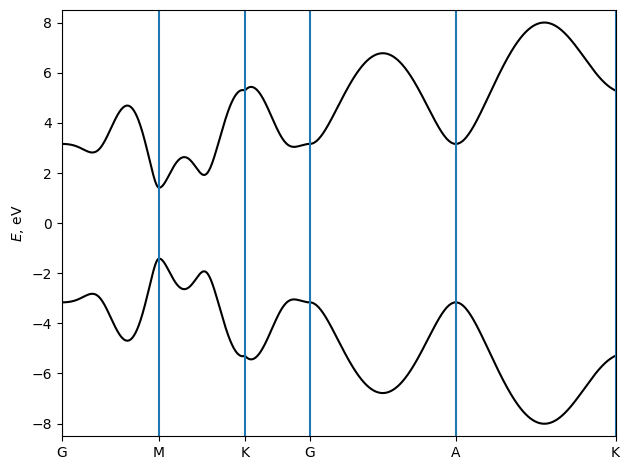

In [27]:
bands.plot_path_fat(path, close_fig=False, show_fig=False)
#plt.title(f"μ={my_model.mu}, t={my_model.t}, t'={my_model.tp}, Δ={my_model.Delta}, t'z={my_model.tpz}, tc={my_model.tc}")
plt.tight_layout()
plt.savefig('par1.pdf')
plt.show()

# Positional Shift

# No tetra

In [50]:
tetra = False
Efermi = np.linspace(-8, +8, 1601)
grid = wberri.Grid(system, NKdiv=[33, 33, 33], NKFFT=[4, 4, 4])

calculators = {}
#calculators["CHCsurf"] = wberri.calculators.static.Hall_classic_FermiSurf(Efermi=Efermi, tetra=tetra)
#calculators["OCsurf"] = wberri.calculators.static.Ohmic_FermiSurf(Efermi=Efermi, tetra=tetra)
#calculators["ZAHC-orb"] = wberri.calculators.static.AHC_Zeeman_orb(Efermi=Efermi, tetra=tetra)
calculators["hall_positional_shift_morb"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"morb_part": True, "external_terms":False},)
calculators["hall_positional_shift_metric"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"metric_part": True, "external_terms":False},)

#ray.init(num_cpus=2)

result_run = wberri.run(system,
        grid=grid,
        calculators = calculators,
        parallel=False,
        adpt_num_iter=50,
        fout_name='./output/ferroaxial-tb',
        restart=False,
        use_irred_kpt=True,
        symmetrize=True
        )

Starting run()
Using the follwing calculators : 
############################################################

 'hall_positional_shift_morb'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A2FE68F10>  : calculator not described
 'hall_positional_shift_metric'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A2D2FE790>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
hall_positional_shift_morb <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A2FE68F10>
hall_positional_shift_metric <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A2D2FE790>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[33 33 33], NKFFT=[4 4 4], NKtot=[132 132 132]
generating K_list
Done in 0.5934426784515381 s 
excluding symmetry-equivalent K-points from initial grid
Done in 4.11074805

In [40]:
import matplotlib as mpl

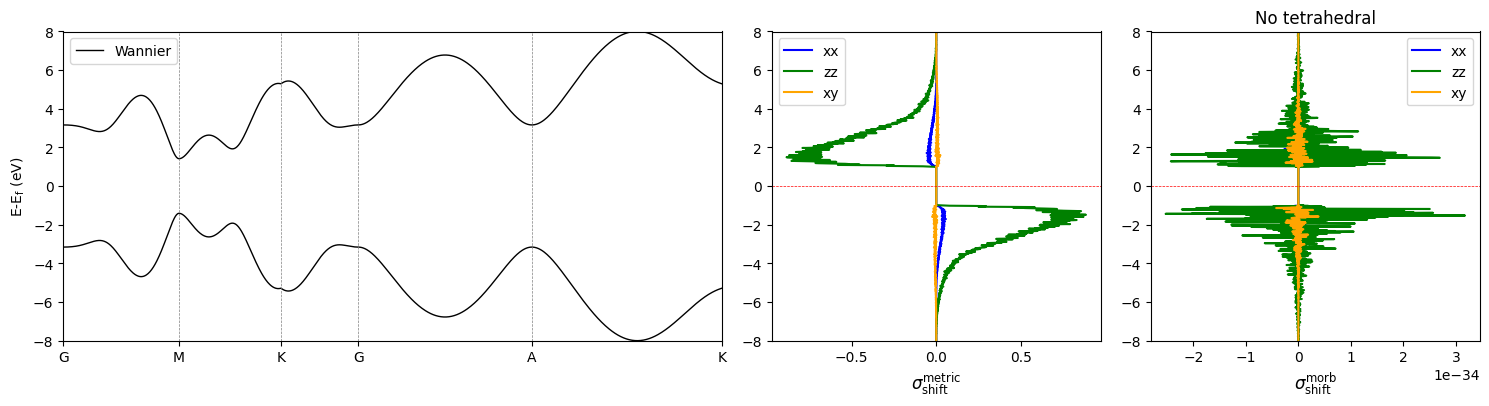

In [72]:
mpl.rcParams['lines.linestyle'] = '--'
mpl.rcParams['lines.linewidth'] = 0.5
mpl.rcParams['lines.color'] = 'gray'

ery = (-8.0, 8.0)

fig, ax = plt.subplots(1,3, figsize=(15,4), gridspec_kw={'width_ratios': [2, 1, 1]})

bands.plot_path_fat(path, iband=None, 
                                        mode="fatband", fatfactor=20, cut_k=False, close_fig=False, 
                                        show_fig=False, axes = ax[0], label = "Wannier",
                                        kwargs_line= {'linestyle' : '-', 'linewidth' : 1})

ax[0].set_ylabel(r'E-$\mathrm{E_f}$ (eV)')

for i in range(50, 51, 1):
    a = np.loadtxt(f"./output/ferroaxial-tb-hall_positional_shift_metric_iter-{i:04d}.dat")
    ax[1].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[1].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[1].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[1].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')      
    a = np.loadtxt(f"./output/ferroaxial-tb-hall_positional_shift_morb_iter-{i:04d}.dat")
    ax[2].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[2].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[2].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[2].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')     

ax[0].set_ylim(ery[0], ery[1])

ax[1].axhline(0, linestyle='--', color='red')
ax[1].legend(loc='upper left')
ax[1].set_ylim(ery[0], ery[1])
#ax[1].set_xlim(-500, 500)
ax[1].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$', fontsize=12)

ax[2].axhline(0, linestyle='--', color='red')
ax[2].legend(loc='upper right')
ax[2].set_ylim(ery[0], ery[1])
#ax[2].set_xlim(-40, 40)
ax[2].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{morb}$', fontsize=12)

plt.tight_layout()
plt.title("No tetrahedral")
plt.savefig("ferro_bands_cond_pos.pdf")

# Tetrahedral

In [68]:
tetra = True
Efermi = np.linspace(-8, +8, 1601)
grid = wberri.Grid(system, NKdiv=[16, 16, 16], NKFFT=[2, 2, 2])

calculators = {}
calculators["hall_positional_shift_morb"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"morb_part": True, 
                                                                                                            "external_terms":False},)
calculators["hall_positional_shift_metric"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"metric_part": True, 
                                                                                                              "external_terms":False},)

#ray.init(num_cpus=2)

result_run = wberri.run(system,
        grid=grid,
        calculators = calculators,
        parallel=False,
        adpt_num_iter=50,
        fout_name='./output/ferroaxial-tb-tetra',
        restart=False,
        use_irred_kpt=True,
        symmetrize=True
        )

Starting run()
Using the follwing calculators : 
############################################################

 'hall_positional_shift_morb'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A389CD350>  : calculator not described
 'hall_positional_shift_metric'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017C06E17E10>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
hall_positional_shift_morb <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A389CD350>
hall_positional_shift_metric <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017C06E17E10>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[16 16 16], NKFFT=[2 2 2], NKtot=[32 32 32]
generating K_list
Done in 0.09793424606323242 s 
excluding symmetry-equivalent K-points from initial grid
Done in 0.5316398143

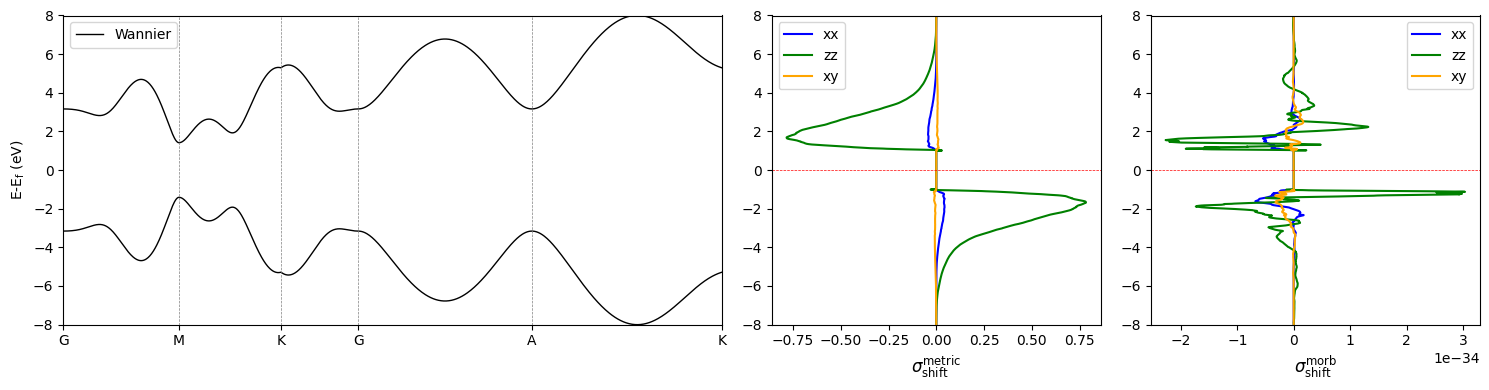

In [73]:
mpl.rcParams['lines.linestyle'] = '--'
mpl.rcParams['lines.linewidth'] = 0.5
mpl.rcParams['lines.color'] = 'gray'

ery = (-8.0, 8.0)

fig, ax = plt.subplots(1,3, figsize=(15,4), gridspec_kw={'width_ratios': [2, 1, 1]})

bands.plot_path_fat(path, iband=None, 
                                        mode="fatband", fatfactor=20, cut_k=False, close_fig=False, 
                                        show_fig=False, axes = ax[0], label = "Wannier",
                                        kwargs_line= {'linestyle' : '-', 'linewidth' : 1})

ax[0].set_ylabel(r'E-$\mathrm{E_f}$ (eV)')

for i in range(50, 51, 1):
    a = np.loadtxt(f"./output/ferroaxial-tb-tetra-hall_positional_shift_metric_iter-{i:04d}.dat")
    ax[1].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[1].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[1].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[1].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')      
    a = np.loadtxt(f"./output/ferroaxial-tb-tetra-hall_positional_shift_morb_iter-{i:04d}.dat")
    ax[2].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[2].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[2].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[2].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')     

ax[0].set_ylim(ery[0], ery[1])

ax[1].axhline(0, linestyle='--', color='red')
ax[1].legend(loc='upper left')
ax[1].set_ylim(ery[0], ery[1])
#ax[1].set_xlim(-500, 500)
ax[1].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$', fontsize=12)

ax[2].axhline(0, linestyle='--', color='red')
ax[2].legend(loc='upper right')
ax[2].set_ylim(ery[0], ery[1])
#ax[2].set_xlim(-40, 40)
ax[2].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{morb}$', fontsize=12)

plt.tight_layout()
plt.savefig("ferro_bands_cond_pos_tetra.pdf")

# Adding symmetry

In [66]:
system_sym = System_PythTB(ptb_model=model_ferroaxial_pythtb(mu=0.0, t=1.0, tp=1.0, Delta=1.0, tpz=1.0, tc=0.0, a=1.0))

system_sym.set_pointgroup(symmetry_gen=["C6z"])

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (23, 2, 2)
Real-space lattice:
 [[ 1.5       -0.8660254  0.       ]
 [ 1.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]
Number of wannier functions: 2
Number of R points: 23
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully


In [70]:
tetra = True
Efermi = np.linspace(-8, +8, 1601)
grid = wberri.Grid(system, NKdiv=[16, 16, 16], NKFFT=[2, 2, 2])

calculators = {}
calculators["hall_positional_shift_morb"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"morb_part": True, 
                                                                                                            "external_terms":False},)
calculators["hall_positional_shift_metric"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"metric_part": True, 
                                                                                                              "external_terms":False},)

#ray.init(num_cpus=2)

result_run = wberri.run(system_sym,
        grid=grid,
        calculators = calculators,
        parallel=False,
        adpt_num_iter=50,
        fout_name='./output/ferroaxial-tb-sym-tetra',
        restart=False,
        use_irred_kpt=True,
        symmetrize=True
        )

Starting run()
Using the follwing calculators : 
############################################################

 'hall_positional_shift_morb'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017AE06420D0>  : calculator not described
 'hall_positional_shift_metric'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A2FCE8A10>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
hall_positional_shift_morb <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017AE06420D0>
hall_positional_shift_metric <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A2FCE8A10>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[16 16 16], NKFFT=[2 2 2], NKtot=[32 32 32]
generating K_list
Done in 0.07167911529541016 s 
excluding symmetry-equivalent K-points from initial grid
Done in 0.4260327816

KeyboardInterrupt: 

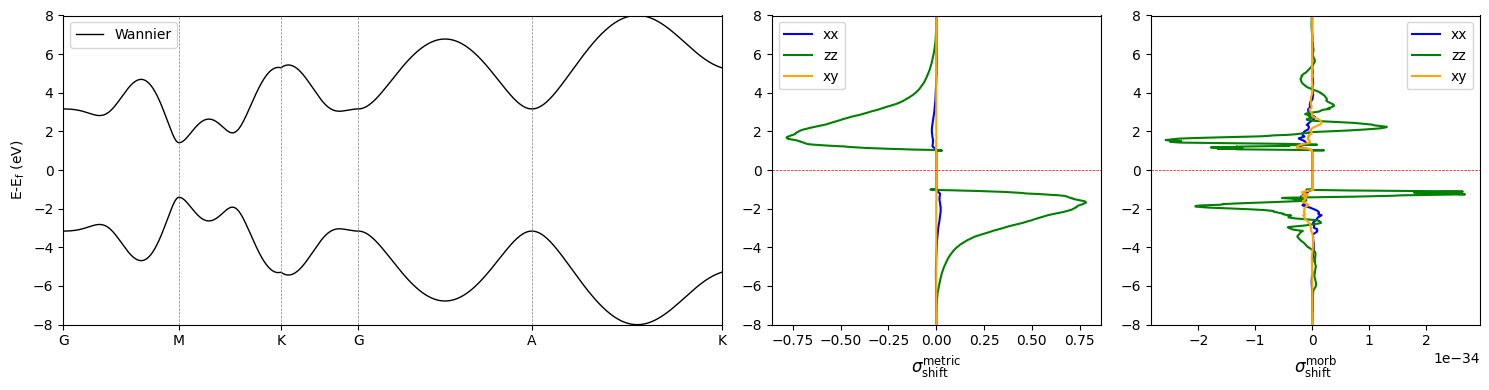

In [77]:
mpl.rcParams['lines.linestyle'] = '--'
mpl.rcParams['lines.linewidth'] = 0.5
mpl.rcParams['lines.color'] = 'gray'

ery = (-8.0, 8.0)

fig, ax = plt.subplots(1,3, figsize=(15,4), gridspec_kw={'width_ratios': [2, 1, 1]})

bands.plot_path_fat(path, iband=None, 
                                        mode="fatband", fatfactor=20, cut_k=False, close_fig=False, 
                                        show_fig=False, axes = ax[0], label = "Wannier",
                                        kwargs_line= {'linestyle' : '-', 'linewidth' : 1})

ax[0].set_ylabel(r'E-$\mathrm{E_f}$ (eV)')

for i in range(50, 51, 1):
    a = np.loadtxt(f"./output/ferroaxial-tb-sym-tetra-hall_positional_shift_metric_iter-{i:04d}.dat")
    ax[1].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[1].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[1].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[1].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')      
    a = np.loadtxt(f"./output/ferroaxial-tb-sym-tetra-hall_positional_shift_morb_iter-{i:04d}.dat")
    ax[2].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[2].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[2].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[2].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')     

ax[0].set_ylim(ery[0], ery[1])

ax[1].axhline(0, linestyle='--', color='red')
ax[1].legend(loc='upper left')
ax[1].set_ylim(ery[0], ery[1])
#ax[1].set_xlim(-500, 500)
ax[1].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$', fontsize=12)

ax[2].axhline(0, linestyle='--', color='red')
ax[2].legend(loc='upper right')
ax[2].set_ylim(ery[0], ery[1])
#ax[2].set_xlim(-40, 40)
ax[2].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{morb}$', fontsize=12)

plt.tight_layout()
plt.savefig("ferro_bands_cond_pos_C6z.pdf")

In [79]:
system_sym_TR = System_PythTB(ptb_model=model_ferroaxial_pythtb(mu=0.0, t=1.0, tp=1.0, Delta=1.0, tpz=1.0, tc=0.0, a=1.0))
system_sym_TR.set_pointgroup(symmetry_gen=["C6z", "TimeReversal"])

Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (23, 2, 2)
Real-space lattice:
 [[ 1.5       -0.8660254  0.       ]
 [ 1.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]
Number of wannier functions: 2
Number of R points: 23
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully


In [80]:
tetra = True
Efermi = np.linspace(-8, +8, 1601)
grid = wberri.Grid(system, NKdiv=[16, 16, 16], NKFFT=[2, 2, 2])

calculators = {}
calculators["hall_positional_shift_morb"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"morb_part": True, 
                                                                                                            "external_terms":False},)
calculators["hall_positional_shift_metric"] = HallPositionalShift(Efermi=Efermi, tetra=tetra, kwargs_formula={"metric_part": True, 
                                                                                                              "external_terms":False},)

#ray.init(num_cpus=2)

result_run = wberri.run(system_sym_TR,
        grid=grid,
        calculators = calculators,
        parallel=False,
        adpt_num_iter=50,
        fout_name='./output/ferroaxial-tb-TR-sym-tetra',
        restart=False,
        use_irred_kpt=True,
        symmetrize=True
        )

Starting run()
Using the follwing calculators : 
############################################################

 'hall_positional_shift_morb'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017B7DE3B850>  : calculator not described
 'hall_positional_shift_metric'  :  <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A384D8ED0>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
hall_positional_shift_morb <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017B7DE3B850>
hall_positional_shift_metric <hall_ps.hall_positional_shift.HallPositionalShift object at 0x0000017A384D8ED0>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[16 16 16], NKFFT=[2 2 2], NKtot=[32 32 32]
generating K_list
Done in 0.06905937194824219 s 
excluding symmetry-equivalent K-points from initial grid
Done in 0.4237220287

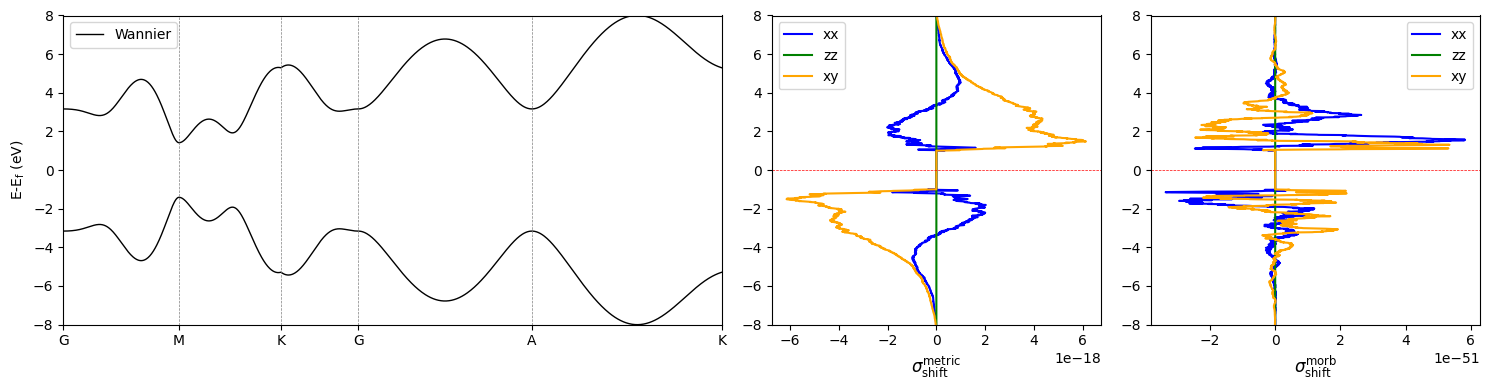

In [82]:
mpl.rcParams['lines.linestyle'] = '--'
mpl.rcParams['lines.linewidth'] = 0.5
mpl.rcParams['lines.color'] = 'gray'

ery = (-8.0, 8.0)

fig, ax = plt.subplots(1,3, figsize=(15,4), gridspec_kw={'width_ratios': [2, 1, 1]})

bands.plot_path_fat(path, iband=None, 
                                        mode="fatband", fatfactor=20, cut_k=False, close_fig=False, 
                                        show_fig=False, axes = ax[0], label = "Wannier",
                                        kwargs_line= {'linestyle' : '-', 'linewidth' : 1})

ax[0].set_ylabel(r'E-$\mathrm{E_f}$ (eV)')

for i in range(50, 51, 1):
    a = np.loadtxt(f"./output/ferroaxial-tb-TR-sym-tetra-hall_positional_shift_metric_iter-{i:04d}.dat")
    ax[1].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[1].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[1].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[1].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')      
    a = np.loadtxt(f"./output/ferroaxial-tb-TR-sym-tetra-hall_positional_shift_morb_iter-{i:04d}.dat")
    ax[2].plot(a[:,1], a[:,0], '-', color = 'blue', linewidth = 1.5, label = 'xx') # xx
    #ax[2].plot(a[:,5], a[:,0], '--', color = 'blue', label = 'yy') 
    ax[2].plot(a[:,9], a[:,0], '-', color = 'green', linewidth = 1.5, label = 'zz')
    ax[2].plot(a[:,2], a[:,0], '-', color = 'orange', linewidth = 1.5, label = 'xy')     

ax[0].set_ylim(ery[0], ery[1])

ax[1].axhline(0, linestyle='--', color='red')
ax[1].legend(loc='upper left')
ax[1].set_ylim(ery[0], ery[1])
#ax[1].set_xlim(-500, 500)
ax[1].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{metric}$', fontsize=12)

ax[2].axhline(0, linestyle='--', color='red')
ax[2].legend(loc='upper right')
ax[2].set_ylim(ery[0], ery[1])
#ax[2].set_xlim(-40, 40)
ax[2].set_xlabel(r'$\sigma_\mathrm{shift}^\mathrm{morb}$', fontsize=12)

plt.tight_layout()
plt.savefig("ferro_bands_cond_pos_C6z_TR.pdf")